# 05 — Final Model Evaluation and Interpretability

This notebook performs the final evaluation of the models selected using
development-set cross-validation.

The protected holdout is used only after the candidate models, preprocessing
pipelines and diagnostic threshold-selection rule have been frozen.

The main objectives are:

1. generate out-of-fold development predictions;
2. examine probability quality and select a diagnostic threshold without using
   the holdout;
3. fit the selected models on the full development sample;
4. evaluate them once on the protected holdout;
5. quantify uncertainty and interpret the resulting models.

No model or hyperparameter will be changed based on holdout performance.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy import sparse
from sklearn.base import clone
from sklearn.exceptions import ConvergenceWarning
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
    train_test_split,
)

RANDOM_STATE = 42
HOLDOUT_SIZE = 0.20
N_SPLITS = 5
N_BOOTSTRAP = 1_000

current_directory = Path.cwd().resolve()

if current_directory.name == "notebooks":
    PROJECT_ROOT = current_directory.parent
else:
    PROJECT_ROOT = current_directory

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import (
    load_application_train,
    make_model_matrices,
    make_protected_split,
)
from src.features import build_feature_schema
from src.modeling import (
    make_logistic_model,
    make_tree_model,
)

## 1. Frozen model-selection decision

Model selection was performed exclusively using cross-validation on the
development sample in Notebook 04.

Histogram gradient boosting is retained as the leading nonlinear candidate.
Unweighted logistic regression is retained as a transparent benchmark.

The protected holdout has not contributed to this decision.

In [2]:
CV_SUMMARY_PATH = (
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "04_baseline_cv_summary.csv"
)

cv_summary = pd.read_csv(
    CV_SUMMARY_PATH
)

cv_summary

,model,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,brier_score_mean,fit_time_mean
0,hist_gradient_boosting,0.762710,0.001847,0.244805,5.614649e-03,0.067697,14.314047
1,logistic_unweighted,0.748896,0.001524,0.227339,4.597128e-03,0.068512,56.815363
2,logistic_balanced,0.748866,0.001628,0.225115,4.583669e-03,0.202260,118.317958
3,dummy_prior,0.500000,0.000000,0.080729,8.986968e-07,0.074212,0.093401


In [3]:
required_models = {
    "hist_gradient_boosting",
    "logistic_unweighted",
}

assert required_models.issubset(
    set(cv_summary["model"])
)

selected_cv_results = (
    cv_summary
    .loc[
        cv_summary["model"].isin(
            required_models
        )
    ]
    .sort_values(
        "roc_auc_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

selected_cv_results

,model,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,brier_score_mean,fit_time_mean
0,hist_gradient_boosting,0.762710,0.001847,0.244805,0.005615,0.067697,14.314047
1,logistic_unweighted,0.748896,0.001524,0.227339,0.004597,0.068512,56.815363


In [4]:
APPLICATION_TRAIN_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "application_train.csv"
)

application_train = load_application_train(
    APPLICATION_TRAIN_PATH
)

development_df, protected_holdout_df = (
    make_protected_split(
        application_train,
        holdout_size=HOLDOUT_SIZE,
        random_state=RANDOM_STATE,
    )
)

(
    X_development_raw,
    y_development,
    development_ids,
) = make_model_matrices(
    development_df
)

development_audit = pd.Series(
    {
        "rows": len(X_development_raw),
        "default_count": int(
            y_development.sum()
        ),
        "default_rate": float(
            y_development.mean()
        ),
        "unique_ids": (
            development_ids.is_unique
        ),
    },
    name="development",
)

development_audit

rows               246008
default_count       19860
default_rate     0.080729
unique_ids           True
Name: development, dtype: object

In [5]:
assert X_development_raw.index.equals(
    y_development.index
)

assert X_development_raw.index.equals(
    development_ids.index
)

assert development_ids.is_unique

In [6]:
feature_schema = build_feature_schema(
    X_development_raw
)

selected_models = {
    "hist_gradient_boosting": (
        make_tree_model(
            feature_schema,
            random_state=RANDOM_STATE,
        )
    ),
    "logistic_unweighted": (
        make_logistic_model(
            feature_schema,
            class_weight=None,
            random_state=RANDOM_STATE,
        )
    ),
}

cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

## 2. Out-of-fold development predictions

Out-of-fold probabilities are generated using the same stratified
cross-validation protocol as in Notebook 04.

These predictions provide approximately unbiased development-set predictions
for calibration diagnostics and threshold analysis. The protected holdout is
not used for these decisions.

In [7]:
oof_probabilities = pd.DataFrame(
    {
        "SK_ID_CURR": (
            development_ids.to_numpy()
        ),
        "TARGET": (
            y_development.to_numpy()
        ),
    },
    index=X_development_raw.index,
)

for model_name, model in selected_models.items():
    print(f"OOF predictions: {model_name}")

    with warnings.catch_warnings():
        warnings.simplefilter(
            "error",
            ConvergenceWarning,
        )

        predicted_probability = (
            cross_val_predict(
                estimator=model,
                X=X_development_raw,
                y=y_development,
                cv=cv,
                method="predict_proba",
                n_jobs=1,
            )[:, 1]
        )

    oof_probabilities[
        model_name
    ] = predicted_probability

OOF predictions: hist_gradient_boosting
OOF predictions: logistic_unweighted


In [8]:
assert oof_probabilities[
    list(selected_models)
].notna().all().all()

assert (
    oof_probabilities[
        list(selected_models)
    ]
    .ge(0)
    .all()
    .all()
)

assert (
    oof_probabilities[
        list(selected_models)
    ]
    .le(1)
    .all()
    .all()
)

oof_probabilities.head()

,SK_ID_CURR,TARGET,hist_gradient_boosting,logistic_unweighted
0,100002,1,0.434801,0.590838
1,100003,0,0.031644,0.023402
2,100004,0,0.046095,0.032112
3,100006,0,0.038679,0.071493
4,100007,0,0.118475,0.092268


In [9]:
oof_metric_rows = []

for model_name in selected_models:
    probabilities = (
        oof_probabilities[model_name]
    )

    oof_metric_rows.append(
        {
            "model": model_name,
            "roc_auc": roc_auc_score(
                y_development,
                probabilities,
            ),
            "average_precision": (
                average_precision_score(
                    y_development,
                    probabilities,
                )
            ),
            "brier_score": brier_score_loss(
                y_development,
                probabilities,
            ),
            "log_loss": log_loss(
                y_development,
                probabilities,
            ),
        }
    )

oof_metrics = (
    pd.DataFrame(oof_metric_rows)
    .sort_values(
        "roc_auc",
        ascending=False,
    )
    .reset_index(drop=True)
)

oof_metrics

,model,roc_auc,average_precision,brier_score,log_loss
0,hist_gradient_boosting,0.761038,0.243470,0.067764,0.245617
1,logistic_unweighted,0.748889,0.226945,0.068512,0.249086


In [10]:
def select_f1_threshold(
    y_true,
    probabilities,
) -> dict:
    precision, recall, thresholds = (
        precision_recall_curve(
            y_true,
            probabilities,
        )
    )

    precision = precision[:-1]
    recall = recall[:-1]

    denominator = precision + recall

    f1_values = np.divide(
        2 * precision * recall,
        denominator,
        out=np.zeros_like(
            denominator,
            dtype=float,
        ),
        where=denominator > 0,
    )

    best_index = int(
        np.nanargmax(f1_values)
    )

    return {
        "threshold": float(
            thresholds[best_index]
        ),
        "precision": float(
            precision[best_index]
        ),
        "recall": float(
            recall[best_index]
        ),
        "f1": float(
            f1_values[best_index]
        ),
    }

threshold_rows = []

for model_name in selected_models:
    result = select_f1_threshold(
        y_development,
        oof_probabilities[model_name],
    )

    threshold_rows.append(
        {
            "model": model_name,
            **result,
        }
    )

development_thresholds = pd.DataFrame(
    threshold_rows
)

development_thresholds


,model,threshold,precision,recall,f1
0,hist_gradient_boosting,0.143454,0.238016,0.438268,0.308494
1,logistic_unweighted,0.148895,0.233210,0.407905,0.296756


## 3. Final protected-holdout evaluation

The candidate models and diagnostic thresholds are now frozen.

Each pipeline is fitted on the complete development sample and evaluated once
on the protected holdout. Holdout results are used for final performance
estimation, not for additional model selection or tuning.

In [11]:
(
    X_holdout_raw,
    y_holdout,
    holdout_ids,
) = make_model_matrices(
    protected_holdout_df
)

assert X_holdout_raw.index.equals(
    y_holdout.index
)

assert X_holdout_raw.index.equals(
    holdout_ids.index
)

assert holdout_ids.is_unique

assert set(development_ids).isdisjoint(
    set(holdout_ids)
)

assert X_development_raw.columns.equals(
    X_holdout_raw.columns
)

split_audit = pd.DataFrame(
    {
        "development": {
            "rows": len(X_development_raw),
            "default_count": int(
                y_development.sum()
            ),
            "default_rate": float(
                y_development.mean()
            ),
            "unique_ids": (
                development_ids.is_unique
            ),
        },
        "holdout": {
            "rows": len(X_holdout_raw),
            "default_count": int(
                y_holdout.sum()
            ),
            "default_rate": float(
                y_holdout.mean()
            ),
            "unique_ids": (
                holdout_ids.is_unique
            ),
        },
    }
)

split_audit

,development,holdout
rows,246008,61503
default_count,19860,4965
default_rate,0.080729,0.080728
unique_ids,True,True


In [12]:
fitted_models = {}
holdout_probabilities = pd.DataFrame(
    {
        "SK_ID_CURR": (
            holdout_ids.to_numpy()
        ),
        "TARGET": (
            y_holdout.to_numpy()
        ),
    },
    index=X_holdout_raw.index,
)

for model_name, model in selected_models.items():
    print(f"Final fit: {model_name}")

    fitted_model = clone(model)

    with warnings.catch_warnings():
        warnings.simplefilter(
            "error",
            ConvergenceWarning,
        )

        fitted_model.fit(
            X_development_raw,
            y_development,
        )

    fitted_models[model_name] = (
        fitted_model
    )

    holdout_probabilities[
        model_name
    ] = fitted_model.predict_proba(
        X_holdout_raw
    )[:, 1]

Final fit: hist_gradient_boosting
Final fit: logistic_unweighted


In [13]:
fitted_tree = fitted_models[
    "hist_gradient_boosting"
]

tree_preprocessing = (
    fitted_tree.named_steps[
        "preprocessing"
    ]
)

tree_classifier = (
    fitted_tree.named_steps[
        "classifier"
    ]
)

tree_feature_names = np.asarray(
    tree_preprocessing
    .get_feature_names_out(),
    dtype=str,
)

expected_categorical_mask = (
    np.char.startswith(
        tree_feature_names,
        "categorical__",
    )
)

fitted_categorical_mask = getattr(
    tree_classifier,
    "is_categorical_",
    None,
)

assert fitted_categorical_mask is not None, (
    "The fitted classifier does not expose "
    "a categorical-feature mask."
)

fitted_categorical_mask = np.asarray(
    fitted_categorical_mask,
    dtype=bool,
)

assert len(fitted_categorical_mask) == len(
    tree_feature_names
)

assert np.array_equal(
    fitted_categorical_mask,
    expected_categorical_mask,
), (
    "Categorical columns emitted by preprocessing "
    "do not match the columns treated as categorical "
    "by HistGradientBoostingClassifier."
)

assert len(tree_feature_names) == (
    tree_classifier.n_features_in_
)

tree_categorical_audit = pd.DataFrame(
    {
        "position": np.arange(
            len(tree_feature_names)
        ),
        "transformed_feature": (
            tree_feature_names
        ),
        "expected_as_categorical": (
            expected_categorical_mask
        ),
        "fitted_as_categorical": (
            fitted_categorical_mask
        ),
    }
)

tree_categorical_parameter = (
    tree_classifier
    .get_params(deep=False)[
        "categorical_features"
    ]
)

print(
    "categorical_features parameter:",
    tree_categorical_parameter,
)

tree_categorical_audit.loc[
    tree_categorical_audit[
        "expected_as_categorical"
    ]
].head(20)

categorical_features parameter: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]


,position,transformed_feature,expected_as_categorical,fitted_as_categorical
0,0,categorical__NAME_CONTRACT_TYPE,True,True
1,1,categorical__CODE_GENDER,True,True
2,2,categorical__FLAG_OWN_CAR,True,True
3,3,categorical__FLAG_OWN_REALTY,True,True
4,4,categorical__NAME_TYPE_SUITE,True,True
5,5,categorical__NAME_INCOME_TYPE,True,True
6,6,categorical__NAME_EDUCATION_TYPE,True,True
7,7,categorical__NAME_FAMILY_STATUS,True,True
8,8,categorical__NAME_HOUSING_TYPE,True,True
9,9,categorical__OCCUPATION_TYPE,True,True


In [14]:
assert holdout_probabilities[
    list(selected_models)
].notna().all().all()

assert (
    holdout_probabilities[
        list(selected_models)
    ]
    .ge(0)
    .all()
    .all()
)

assert (
    holdout_probabilities[
        list(selected_models)
    ]
    .le(1)
    .all()
    .all()
)

In [15]:
holdout_metric_rows = []

for model_name in selected_models:
    probabilities = (
        holdout_probabilities[model_name]
    )

    holdout_metric_rows.append(
        {
            "model": model_name,
            "roc_auc": roc_auc_score(
                y_holdout,
                probabilities,
            ),
            "average_precision": (
                average_precision_score(
                    y_holdout,
                    probabilities,
                )
            ),
            "brier_score": brier_score_loss(
                y_holdout,
                probabilities,
            ),
            "log_loss": log_loss(
                y_holdout,
                probabilities,
            ),
        }
    )

holdout_probability_metrics = (
    pd.DataFrame(holdout_metric_rows)
    .sort_values(
        "roc_auc",
        ascending=False,
    )
    .reset_index(drop=True)
)

holdout_probability_metrics

,model,roc_auc,average_precision,brier_score,log_loss
0,hist_gradient_boosting,0.764834,0.253025,0.067374,0.244170
1,logistic_unweighted,0.752294,0.237211,0.068106,0.247664


In [16]:
holdout_threshold_rows = []

for row in development_thresholds.itertuples(
    index=False
):
    probabilities = (
        holdout_probabilities[row.model]
    )

    predictions = (
        probabilities >= row.threshold
    ).astype(int)

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            y_holdout,
            predictions,
            average="binary",
            zero_division=0,
        )
    )

    tn, fp, fn, tp = confusion_matrix(
        y_holdout,
        predictions,
    ).ravel()

    holdout_threshold_rows.append(
        {
            "model": row.model,
            "threshold_source": (
                "development_oof_max_f1"
            ),
            "threshold": row.threshold,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "true_negative": tn,
            "false_positive": fp,
            "false_negative": fn,
            "true_positive": tp,
        }
    )

holdout_threshold_metrics = pd.DataFrame(
    holdout_threshold_rows
)

holdout_threshold_metrics

,model,threshold_source,threshold,precision,recall,f1,true_negative,false_positive,false_negative,true_positive
0,hist_gradient_boosting,development_oof_max_f1,0.143454,0.242896,0.445921,0.314489,49637,6901,2751,2214
1,logistic_unweighted,development_oof_max_f1,0.148895,0.236234,0.407855,0.299180,49991,6547,2940,2025


In [17]:
holdout_threshold_metrics = (
    holdout_threshold_metrics
    .assign(
        specificity=lambda table: (
            table["true_negative"]
            / (
                table["true_negative"]
                + table["false_positive"]
            )
        ),
        false_positive_rate=lambda table: (
            table["false_positive"]
            / (
                table["true_negative"]
                + table["false_positive"]
            )
        ),
        flagged_high_risk_rate=lambda table: (
            (
                table["true_positive"]
                + table["false_positive"]
            )
            / len(y_holdout)
        ),
        default_detection_rate=lambda table: (
            table["true_positive"]
            / (
                table["true_positive"]
                + table["false_negative"]
            )
        ),
    )
)

holdout_threshold_metrics

,model,threshold_source,threshold,precision,recall,f1,true_negative,false_positive,false_negative,true_positive,specificity,false_positive_rate,flagged_high_risk_rate,default_detection_rate
0,hist_gradient_boosting,development_oof_max_f1,0.143454,0.242896,0.445921,0.314489,49637,6901,2751,2214,0.877941,0.122059,0.148204,0.445921
1,logistic_unweighted,development_oof_max_f1,0.148895,0.236234,0.407855,0.299180,49991,6547,2940,2025,0.884202,0.115798,0.139375,0.407855


## 4. Statistical uncertainty

Point estimates depend on the particular applicants assigned to the protected
holdout. Paired nonparametric bootstrap resampling is therefore used to
construct 95% percentile confidence intervals.

The same sampled applicant indices are used for both models so that model
differences are estimated through paired comparisons.

In [18]:
METRIC_FUNCTIONS = {
    "roc_auc": roc_auc_score,
    "average_precision": (
        average_precision_score
    ),
    "brier_score": brier_score_loss,
    "log_loss": lambda y_true, probability: (
        log_loss(
            y_true,
            probability,
            labels=[0, 1],
        )
    ),
}

def bootstrap_probability_scores(
    y_true,
    probability_table,
    n_bootstrap=1_000,
    random_state=42,
):
    y_array = np.asarray(
        y_true,
        dtype=int,
    )

    probability_arrays = {
        model_name: np.asarray(
            probability_table[model_name],
            dtype=float,
        )
        for model_name in probability_table.columns
    }

    random_generator = (
        np.random.default_rng(
            random_state
        )
    )

    n_observations = len(y_array)
    rows = []

    for bootstrap_id in range(
        n_bootstrap
    ):
        sampled_positions = (
            random_generator.integers(
                low=0,
                high=n_observations,
                size=n_observations,
            )
        )

        sampled_target = y_array[
            sampled_positions
        ]

        if np.unique(
            sampled_target
        ).size < 2:
            continue

        for (
            model_name,
            probabilities,
        ) in probability_arrays.items():
            sampled_probabilities = (
                probabilities[
                    sampled_positions
                ]
            )

            for (
                metric_name,
                metric_function,
            ) in METRIC_FUNCTIONS.items():
                rows.append(
                    {
                        "bootstrap_id": (
                            bootstrap_id
                        ),
                        "model": model_name,
                        "metric": metric_name,
                        "value": metric_function(
                            sampled_target,
                            sampled_probabilities,
                        ),
                    }
                )

        if (
            bootstrap_id + 1
        ) % 100 == 0:
            print(
                f"{bootstrap_id + 1} "
                "bootstrap samples completed"
            )

    return pd.DataFrame(rows)

In [19]:
bootstrap_scores = (
    bootstrap_probability_scores(
        y_true=y_holdout,
        probability_table=(
            holdout_probabilities[
                list(selected_models)
            ]
        ),
        n_bootstrap=N_BOOTSTRAP,
        random_state=RANDOM_STATE,
    )
)

bootstrap_scores.shape

100 bootstrap samples completed
200 bootstrap samples completed
300 bootstrap samples completed
400 bootstrap samples completed
500 bootstrap samples completed
600 bootstrap samples completed
700 bootstrap samples completed
800 bootstrap samples completed
900 bootstrap samples completed
1000 bootstrap samples completed


(8000, 4)

In [20]:
point_estimates = (
    holdout_probability_metrics
    .melt(
        id_vars="model",
        value_vars=list(
            METRIC_FUNCTIONS
        ),
        var_name="metric",
        value_name="estimate",
    )
)

bootstrap_intervals = (
    bootstrap_scores
    .groupby(
        ["model", "metric"]
    )["value"]
    .agg(
        lower_bound=lambda values: (
            values.quantile(0.025)
        ),
        upper_bound=lambda values: (
            values.quantile(0.975)
        ),
    )
    .reset_index()
)

holdout_metric_intervals = (
    point_estimates
    .merge(
        bootstrap_intervals,
        on=["model", "metric"],
        validate="one_to_one",
    )
    .sort_values(
        ["metric", "model"]
    )
    .reset_index(drop=True)
)

holdout_metric_intervals

,model,metric,estimate,lower_bound,upper_bound
0,hist_gradient_boosting,average_precision,0.253025,0.241487,0.265405
1,logistic_unweighted,average_precision,0.237211,0.226391,0.249555
2,hist_gradient_boosting,brier_score,0.067374,0.065869,0.068943
3,logistic_unweighted,brier_score,0.068106,0.066594,0.069648
4,hist_gradient_boosting,log_loss,0.244170,0.239715,0.248995
5,logistic_unweighted,log_loss,0.247664,0.243230,0.252507
6,hist_gradient_boosting,roc_auc,0.764834,0.757381,0.771783
7,logistic_unweighted,roc_auc,0.752294,0.744504,0.759480


In [21]:
bootstrap_differences = (
    bootstrap_scores
    .pivot(
        index=[
            "bootstrap_id",
            "metric",
        ],
        columns="model",
        values="value",
    )
    .assign(
        difference=lambda table: (
            table[
                "hist_gradient_boosting"
            ]
            - table[
                "logistic_unweighted"
            ]
        )
    )
    .reset_index()
)

point_difference_table = (
    point_estimates
    .pivot(
        index="metric",
        columns="model",
        values="estimate",
    )
)

point_difference_table[
    "difference"
] = (
    point_difference_table[
        "hist_gradient_boosting"
    ]
    - point_difference_table[
        "logistic_unweighted"
    ]
)

difference_intervals = (
    bootstrap_differences
    .groupby("metric")[
        "difference"
    ]
    .agg(
        lower_bound=lambda values: (
            values.quantile(0.025)
        ),
        upper_bound=lambda values: (
            values.quantile(0.975)
        ),
    )
)

holdout_model_differences = (
    point_difference_table[
        ["difference"]
    ]
    .join(difference_intervals)
    .reset_index()
)

holdout_model_differences

,metric,difference,lower_bound,upper_bound
0,average_precision,0.015814,0.009955,0.021733
1,brier_score,-0.000732,-0.000940,-0.000528
2,log_loss,-0.003494,-0.004280,-0.002762
3,roc_auc,0.012539,0.010111,0.015467


### Holdout uncertainty results

Paired bootstrap comparisons consistently favor histogram gradient boosting.

Compared with unweighted logistic regression, histogram gradient boosting
increases ROC-AUC by approximately 0.015 and average precision by 0.021.
It also reduces both Brier score and log-loss.

All four paired 95% confidence intervals exclude zero. This provides evidence
that the observed holdout differences are not explained solely by sampling
variability within this holdout sample.

The improvement in ranking performance is practically relevant, particularly
for average precision. The Brier-score improvement is statistically clear but
small in absolute magnitude.

These intervals quantify sampling uncertainty under the current random holdout
design. They do not establish temporal, geographical or out-of-population
stability.

## 5. Probability calibration

Calibration compares predicted probabilities with observed default frequencies.

Applicants are divided into equal-frequency bins based on predicted probability.
Within each bin, the mean predicted probability is compared with the observed
default rate.

This analysis is descriptive. It is not used to recalibrate or modify the models
after observing the protected holdout.

In [22]:
def make_calibration_table(
    y_true,
    probabilities,
    model_name,
    n_bins=10,
):
    calibration_data = pd.DataFrame(
        {
            "target": np.asarray(
                y_true,
                dtype=int,
            ),
            "predicted_probability": (
                np.asarray(
                    probabilities,
                    dtype=float,
                )
            ),
        }
    )

    calibration_data["probability_bin"] = (
        pd.qcut(
            calibration_data[
                "predicted_probability"
            ],
            q=n_bins,
            labels=False,
            duplicates="drop",
        )
    )

    calibration_table = (
        calibration_data
        .groupby(
            "probability_bin",
            observed=True,
        )
        .agg(
            applicant_count=(
                "target",
                "size",
            ),
            default_count=(
                "target",
                "sum",
            ),
            mean_predicted_probability=(
                "predicted_probability",
                "mean",
            ),
            observed_default_rate=(
                "target",
                "mean",
            ),
            minimum_probability=(
                "predicted_probability",
                "min",
            ),
            maximum_probability=(
                "predicted_probability",
                "max",
            ),
        )
        .reset_index()
    )

    calibration_table.insert(
        0,
        "model",
        model_name,
    )

    calibration_table[
        "calibration_gap"
    ] = (
        calibration_table[
            "observed_default_rate"
        ]
        - calibration_table[
            "mean_predicted_probability"
        ]
    )

    return calibration_table

In [23]:
calibration_tables = []

for model_name in selected_models:
    model_calibration_table = (
        make_calibration_table(
            y_true=y_holdout,
            probabilities=(
                holdout_probabilities[
                    model_name
                ]
            ),
            model_name=model_name,
            n_bins=10,
        )
    )

    calibration_tables.append(
        model_calibration_table
    )

holdout_calibration_table = (
    pd.concat(
        calibration_tables,
        ignore_index=True,
    )
)

holdout_calibration_table.round(4)

,model,probability_bin,applicant_count,default_count,mean_predicted_probability,observed_default_rate,minimum_probability,maximum_probability,calibration_gap
0,hist_gradient_boosting,0,6151,68,0.0161,0.0111,0.0062,0.0201,-0.0051
1,hist_gradient_boosting,1,6150,111,0.0233,0.0180,0.0201,0.0264,-0.0052
2,hist_gradient_boosting,2,6150,180,0.0297,0.0293,0.0264,0.0332,-0.0005
3,hist_gradient_boosting,3,6150,207,0.0371,0.0337,0.0332,0.0412,-0.0034
4,hist_gradient_boosting,4,6151,262,0.0462,0.0426,0.0412,0.0516,-0.0036
5,hist_gradient_boosting,5,6150,373,0.0581,0.0607,0.0516,0.0653,0.0026
6,hist_gradient_boosting,6,6150,515,0.0749,0.0837,0.0653,0.0857,0.0089
7,hist_gradient_boosting,7,6150,613,0.1002,0.0997,0.0857,0.1175,-0.0005
8,hist_gradient_boosting,8,6150,930,0.1446,0.1512,0.1175,0.1803,0.0066
9,hist_gradient_boosting,9,6151,1706,0.2728,0.2774,0.1803,0.6783,0.0046


In [24]:
assert (
    holdout_calibration_table
    .groupby("model")[
        "applicant_count"
    ]
    .sum()
    .eq(len(y_holdout))
    .all()
)

assert (
    holdout_calibration_table[
        "default_count"
    ].sum()
    == len(selected_models)
    * int(y_holdout.sum())
)

In [25]:
calibration_summary_rows = []

holdout_default_rate = float(
    y_holdout.mean()
)

for model_name in selected_models:
    model_table = (
        holdout_calibration_table
        .loc[
            holdout_calibration_table[
                "model"
            ].eq(model_name)
        ]
    )

    weights = (
        model_table[
            "applicant_count"
        ].to_numpy()
    )

    absolute_gaps = (
        model_table[
            "calibration_gap"
        ]
        .abs()
        .to_numpy()
    )

    mean_predicted_probability = float(
        holdout_probabilities[
            model_name
        ].mean()
    )

    calibration_summary_rows.append(
        {
            "model": model_name,
            "holdout_default_rate": (
                holdout_default_rate
            ),
            "mean_predicted_probability": (
                mean_predicted_probability
            ),
            "mean_probability_gap": (
                mean_predicted_probability
                - holdout_default_rate
            ),
            "binned_expected_calibration_error": (
                np.average(
                    absolute_gaps,
                    weights=weights,
                )
            ),
            "maximum_absolute_bin_gap": (
                absolute_gaps.max()
            ),
        }
    )

holdout_calibration_summary = (
    pd.DataFrame(
        calibration_summary_rows
    )
)

holdout_calibration_summary.round(4)

,model,holdout_default_rate,mean_predicted_probability,mean_probability_gap,binned_expected_calibration_error,maximum_absolute_bin_gap
0,hist_gradient_boosting,0.0807,0.0803,-0.0004,0.0041,0.0089
1,logistic_unweighted,0.0807,0.0805,-0.0003,0.0031,0.0095


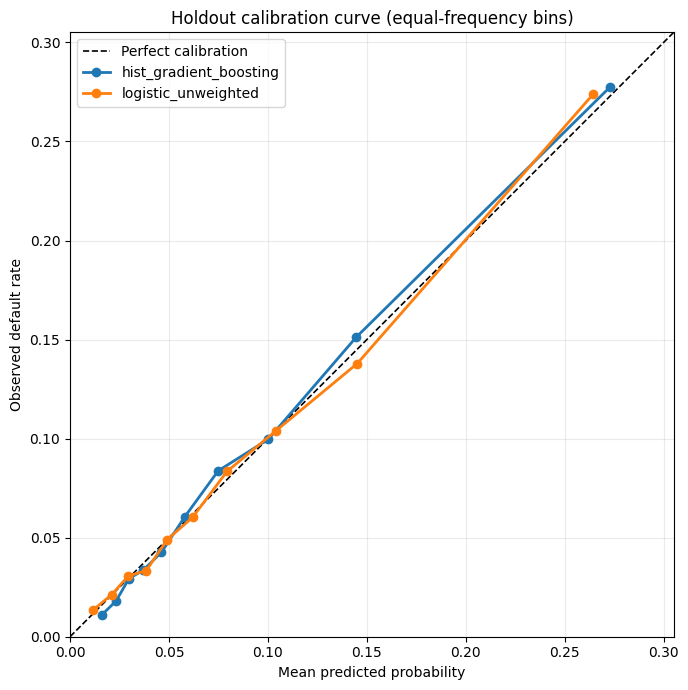

In [26]:
MODEL_COLORS = {
    "hist_gradient_boosting": (
        "tab:blue"
    ),
    "logistic_unweighted": (
        "tab:orange"
    ),
}

fig, ax = plt.subplots(
    figsize=(7, 7)
)

maximum_displayed_rate = max(
    holdout_calibration_table[
        "mean_predicted_probability"
    ].max(),
    holdout_calibration_table[
        "observed_default_rate"
    ].max(),
)

axis_limit = min(
    1.0,
    max(
        0.20,
        maximum_displayed_rate * 1.10,
    ),
)

ax.plot(
    [0, axis_limit],
    [0, axis_limit],
    linestyle="--",
    color="black",
    linewidth=1.2,
    label="Perfect calibration",
)

for model_name in selected_models:
    model_table = (
        holdout_calibration_table
        .loc[
            holdout_calibration_table[
                "model"
            ].eq(model_name)
        ]
        .sort_values(
            "mean_predicted_probability"
        )
    )

    ax.plot(
        model_table[
            "mean_predicted_probability"
        ],
        model_table[
            "observed_default_rate"
        ],
        marker="o",
        linewidth=2,
        color=MODEL_COLORS[
            model_name
        ],
        label=model_name,
    )

ax.set(
    xlim=(0, axis_limit),
    ylim=(0, axis_limit),
    xlabel="Mean predicted probability",
    ylabel="Observed default rate",
    title=(
        "Holdout calibration curve "
        "(equal-frequency bins)"
    ),
)

ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

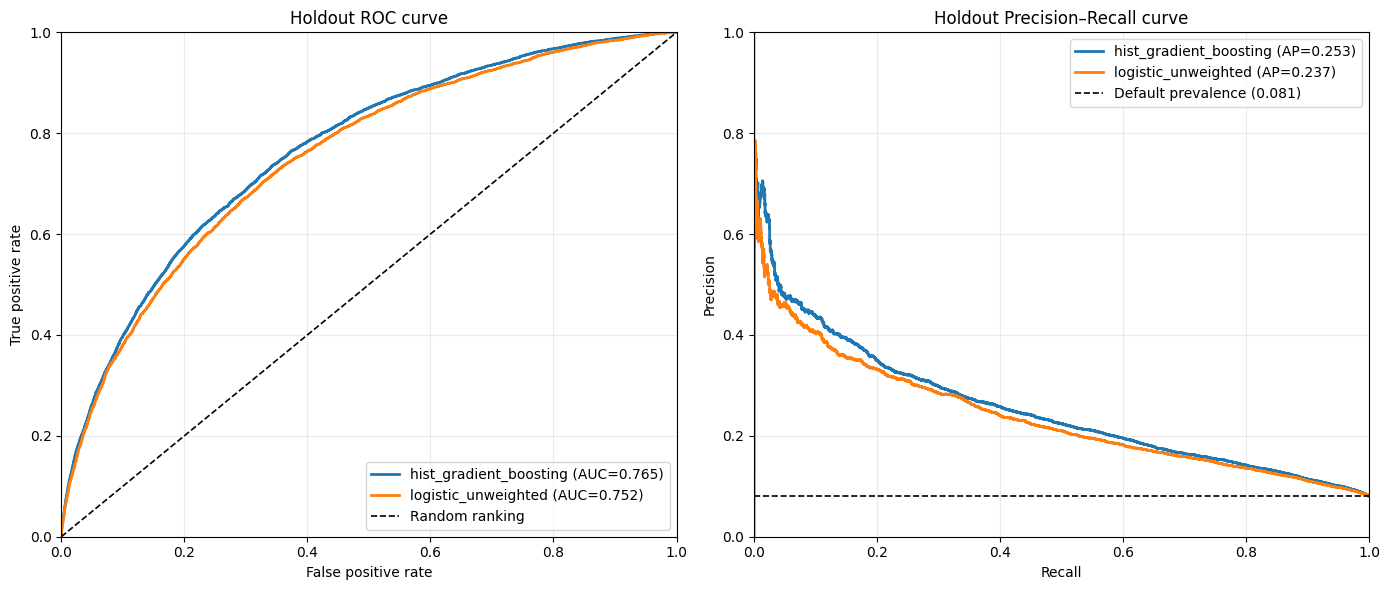

In [27]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 6),
)

for model_name in selected_models:
    probabilities = (
        holdout_probabilities[
            model_name
        ]
    )

    false_positive_rate, true_positive_rate, _ = (
        roc_curve(
            y_holdout,
            probabilities,
        )
    )

    precision, recall, _ = (
        precision_recall_curve(
            y_holdout,
            probabilities,
        )
    )

    roc_auc = roc_auc_score(
        y_holdout,
        probabilities,
    )

    average_precision = (
        average_precision_score(
            y_holdout,
            probabilities,
        )
    )

    axes[0].plot(
        false_positive_rate,
        true_positive_rate,
        linewidth=2,
        color=MODEL_COLORS[
            model_name
        ],
        label=(
            f"{model_name} "
            f"(AUC={roc_auc:.3f})"
        ),
    )

    axes[1].plot(
        recall,
        precision,
        linewidth=2,
        color=MODEL_COLORS[
            model_name
        ],
        label=(
            f"{model_name} "
            f"(AP={average_precision:.3f})"
        ),
    )

axes[0].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    linewidth=1.2,
    label="Random ranking",
)

axes[1].axhline(
    y=holdout_default_rate,
    linestyle="--",
    color="black",
    linewidth=1.2,
    label=(
        "Default prevalence "
        f"({holdout_default_rate:.3f})"
    ),
)

axes[0].set(
    xlim=(0, 1),
    ylim=(0, 1),
    xlabel="False positive rate",
    ylabel="True positive rate",
    title="Holdout ROC curve",
)

axes[1].set(
    xlim=(0, 1),
    ylim=(0, 1),
    xlabel="Recall",
    ylabel="Precision",
    title="Holdout Precision–Recall curve",
)

for ax in axes:
    ax.legend()
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

### Calibration findings

Both models are well calibrated at the portfolio level. Their mean predicted
default probabilities are within approximately 0.0003 of the observed holdout
default rate.

Unweighted logistic regression has slightly lower binned calibration error.
Histogram gradient boosting tends to overestimate risk in several low-risk
deciles and underestimate risk in the highest-risk decile. In its top decile,
the observed default rate is 0.2848 compared with a mean predicted probability
of 0.2726.

Despite this slightly larger binned calibration error, histogram gradient
boosting achieves better Brier score and log-loss. This is not contradictory:
these proper scoring rules reflect both probability calibration and predictive
resolution, whereas binned calibration measures depend on the selected binning
scheme.

No post-holdout recalibration is performed in this notebook.

## 6. Diagnostic classification results

The following confusion matrices use thresholds selected by maximizing F1 on
out-of-fold development predictions.

They describe one possible operating point but do not represent final credit
approval rules. Business thresholds require explicit costs, revenues and risk
constraints.

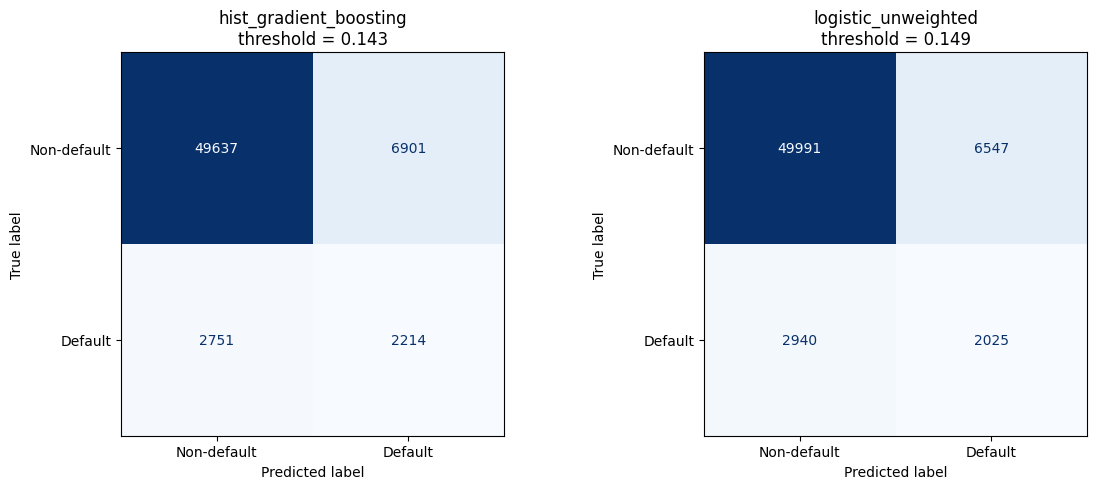

In [28]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(development_thresholds),
    figsize=(12, 5),
)

for ax, row in zip(
    axes,
    development_thresholds.itertuples(
        index=False
    ),
):
    probabilities = holdout_probabilities[
        row.model
    ]

    predictions = (
        probabilities >= row.threshold
    ).astype(int)

    ConfusionMatrixDisplay.from_predictions(
        y_holdout,
        predictions,
        display_labels=[
            "Non-default",
            "Default",
        ],
        cmap="Blues",
        values_format="d",
        colorbar=False,
        ax=ax,
    )

    ax.set_title(
        f"{row.model}\n"
        f"threshold = {row.threshold:.3f}"
    )

plt.tight_layout()
plt.show()

## 7. Logistic-regression interpretation

Logistic-regression coefficients provide a global description of associations
between transformed features and predicted default log-odds.

Positive coefficients increase predicted default risk, while negative
coefficients decrease it, holding the remaining transformed features fixed.

These coefficients describe predictive associations and must not be interpreted
as causal effects.

In [29]:
fitted_logistic = fitted_models[
    "logistic_unweighted"
]

logistic_preprocessing = (
    fitted_logistic.named_steps[
        "preprocessing"
    ]
)

logistic_classifier = (
    fitted_logistic.named_steps[
        "classifier"
    ]
)

logistic_feature_names = (
    logistic_preprocessing
    .get_feature_names_out()
)

logistic_coefficient_values = (
    logistic_classifier.coef_.ravel()
)

assert len(logistic_feature_names) == len(
    logistic_coefficient_values
)

logistic_coefficients = pd.DataFrame(
    {
        "feature": logistic_feature_names,
        "coefficient": (
            logistic_coefficient_values
        ),
    }
)

logistic_coefficients[
    "absolute_coefficient"
] = (
    logistic_coefficients[
        "coefficient"
    ].abs()
)

logistic_coefficients[
    "odds_ratio"
] = np.exp(
    logistic_coefficients[
        "coefficient"
    ]
)

logistic_coefficients[
    "display_feature"
] = (
    logistic_coefficients["feature"]
    .str.replace(
        "numerical__",
        "",
        regex=False,
    )
    .str.replace(
        "categorical__",
        "",
        regex=False,
    )
)

logistic_coefficients = (
    logistic_coefficients
    .sort_values(
        "absolute_coefficient",
        ascending=False,
    )
    .reset_index(drop=True)
)

logistic_coefficients.head(20)

,feature,coefficient,absolute_coefficient,odds_ratio,display_feature
0,categorical__NAME_INCOME_TYPE_Pensioner,-1.112779,1.112779,0.328644,NAME_INCOME_TYPE_Pensioner
1,categorical__NAME_EDUCATION_TYPE_Academic degree,-1.071673,1.071673,0.342435,NAME_EDUCATION_TYPE_Academic degree
2,categorical__NAME_INCOME_TYPE_Unemployed,0.855017,0.855017,2.351414,NAME_INCOME_TYPE_Unemployed
3,categorical__ORGANIZATION_TYPE_Realtor,0.704451,0.704451,2.022736,ORGANIZATION_TYPE_Realtor
4,categorical__ORGANIZATION_TYPE_Legal Services,0.673220,0.673220,1.960540,ORGANIZATION_TYPE_Legal Services
5,categorical__ORGANIZATION_TYPE_Trade: type 4,-0.592429,0.592429,0.552982,ORGANIZATION_TYPE_Trade: type 4
6,categorical__ORGANIZATION_TYPE_Trade: type 5,-0.590344,0.590344,0.554137,ORGANIZATION_TYPE_Trade: type 5
7,categorical__NAME_INCOME_TYPE_Student,-0.579908,0.579908,0.559950,NAME_INCOME_TYPE_Student
8,categorical__ORGANIZATION_TYPE_Transport: type 3,0.550662,0.550662,1.734401,ORGANIZATION_TYPE_Transport: type 3
9,numerical__AMT_GOODS_PRICE,-0.527577,0.527577,0.590033,AMT_GOODS_PRICE


In [30]:
X_logistic_development = (
    logistic_preprocessing.transform(
        X_development_raw
    )
)

if sparse.issparse(
    X_logistic_development
):
    feature_nonzero_counts = np.asarray(
        X_logistic_development.getnnz(
            axis=0
        )
    ).ravel()
else:
    feature_nonzero_counts = np.count_nonzero(
        X_logistic_development,
        axis=0,
    )

logistic_feature_support = pd.DataFrame(
    {
        "feature": logistic_feature_names,
        "nonzero_count": (
            feature_nonzero_counts
        ),
    }
)

logistic_coefficients = (
    logistic_coefficients
    .drop(
        columns=[
            "nonzero_count",
            "category_count",
            "category_rate",
        ],
        errors="ignore",
    )
    .merge(
        logistic_feature_support,
        on="feature",
        validate="one_to_one",
    )
)

is_categorical_coefficient = (
    logistic_coefficients[
        "feature"
    ].str.startswith(
        "categorical__"
    )
)

logistic_coefficients[
    "category_count"
] = np.where(
    is_categorical_coefficient,
    logistic_coefficients[
        "nonzero_count"
    ],
    np.nan,
)

logistic_coefficients[
    "category_rate"
] = (
    logistic_coefficients[
        "category_count"
    ]
    / len(X_development_raw)
)

logistic_coefficients = (
    logistic_coefficients
    .sort_values(
        "absolute_coefficient",
        ascending=False,
    )
    .reset_index(drop=True)
)

logistic_coefficients[
    [
        "feature",
        "coefficient",
        "odds_ratio",
        "category_count",
        "category_rate",
    ]
].head(25)

,feature,coefficient,odds_ratio,category_count,category_rate
0,categorical__NAME_INCOME_TYPE_Pensioner,-1.112779,0.328644,44134.0,0.179401
1,categorical__NAME_EDUCATION_TYPE_Academic degree,-1.071673,0.342435,124.0,0.000504
2,categorical__NAME_INCOME_TYPE_Unemployed,0.855017,2.351414,17.0,0.000069
3,categorical__ORGANIZATION_TYPE_Realtor,0.704451,2.022736,324.0,0.001317
4,categorical__ORGANIZATION_TYPE_Legal Services,0.673220,1.960540,250.0,0.001016
5,categorical__ORGANIZATION_TYPE_Trade: type 4,-0.592429,0.552982,52.0,0.000211
6,categorical__ORGANIZATION_TYPE_Trade: type 5,-0.590344,0.554137,40.0,0.000163
7,categorical__NAME_INCOME_TYPE_Student,-0.579908,0.559950,11.0,0.000045
8,categorical__ORGANIZATION_TYPE_Transport: type 3,0.550662,1.734401,964.0,0.003919
9,numerical__AMT_GOODS_PRICE,-0.527577,0.590033,NaN,NaN


In [31]:
top_positive_coefficients = (
    logistic_coefficients
    .nlargest(15, "coefficient")
    [
        [
            "feature",
            "coefficient",
            "odds_ratio",
            "category_count",
            "category_rate",
        ]
    ]
)

top_negative_coefficients = (
    logistic_coefficients
    .nsmallest(15, "coefficient")
    [
        [
            "feature",
            "coefficient",
            "odds_ratio",
            "category_count",
            "category_rate",
        ]
    ]
)


In [32]:
top_positive_coefficients

,feature,coefficient,odds_ratio,category_count,category_rate
2,categorical__NAME_INCOME_TYPE_Unemployed,0.855017,2.351414,17.0,0.000069
3,categorical__ORGANIZATION_TYPE_Realtor,0.704451,2.022736,324.0,0.001317
4,categorical__ORGANIZATION_TYPE_Legal Services,0.673220,1.960540,250.0,0.001016
8,categorical__ORGANIZATION_TYPE_Transport: type 3,0.550662,1.734401,964.0,0.003919
18,numerical__AMT_CREDIT,0.349598,1.418497,NaN,NaN
19,categorical__ORGANIZATION_TYPE_Industry: type 8,0.348296,1.416652,19.0,0.000077
27,numerical__BASEMENTAREA_MEDI,0.298210,1.347445,NaN,NaN
30,categorical__ORGANIZATION_TYPE_Construction,0.278622,1.321308,5399.0,0.021946
32,categorical__ORGANIZATION_TYPE_Cleaning,0.275959,1.317794,212.0,0.000862
34,categorical__ORGANIZATION_TYPE_Advertising,0.274723,1.316166,331.0,0.001345


In [33]:
top_negative_coefficients

,feature,coefficient,odds_ratio,category_count,category_rate
0,categorical__NAME_INCOME_TYPE_Pensioner,-1.112779,0.328644,44134.0,0.179401
1,categorical__NAME_EDUCATION_TYPE_Academic degree,-1.071673,0.342435,124.0,0.000504
5,categorical__ORGANIZATION_TYPE_Trade: type 4,-0.592429,0.552982,52.0,0.000211
6,categorical__ORGANIZATION_TYPE_Trade: type 5,-0.590344,0.554137,40.0,0.000163
7,categorical__NAME_INCOME_TYPE_Student,-0.579908,0.559950,11.0,0.000045
9,numerical__AMT_GOODS_PRICE,-0.527577,0.590033,NaN,NaN
10,categorical__FLAG_OWN_CAR_Y,-0.509799,0.600616,83595.0,0.339806
11,numerical__EXT_SOURCE_3,-0.489299,0.613056,NaN,NaN
12,categorical__ORGANIZATION_TYPE_Industry: type 12,-0.484548,0.615976,293.0,0.001191
13,categorical__ORGANIZATION_TYPE_Military,-0.463866,0.628848,2113.0,0.008589


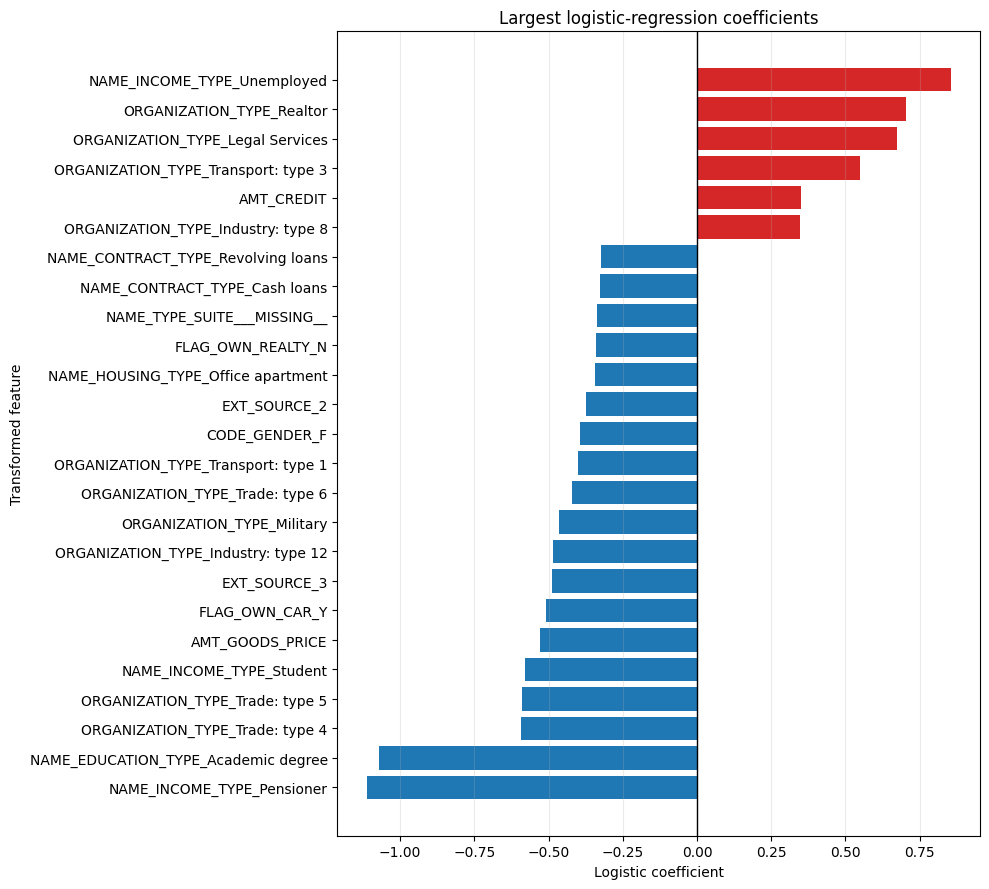

In [34]:
coefficient_plot_data = (
    logistic_coefficients
    .nlargest(
        25,
        "absolute_coefficient",
    )
    .sort_values("coefficient")
)

coefficient_colors = np.where(
    coefficient_plot_data[
        "coefficient"
    ].ge(0),
    "tab:red",
    "tab:blue",
)

fig, ax = plt.subplots(
    figsize=(10, 9)
)

ax.barh(
    coefficient_plot_data[
        "display_feature"
    ],
    coefficient_plot_data[
        "coefficient"
    ],
    color=coefficient_colors,
)

ax.axvline(
    0,
    color="black",
    linewidth=1,
)

ax.set(
    xlabel="Logistic coefficient",
    ylabel="Transformed feature",
    title=(
        "Largest logistic-regression "
        "coefficients"
    ),
)

ax.grid(
    axis="x",
    alpha=0.25,
)

plt.tight_layout()
plt.show()

## 8. Histogram gradient-boosting permutation importance

Permutation importance measures the decrease in holdout average precision after
a transformed feature is randomly shuffled.

A large positive decrease indicates that the fitted model relies strongly on
that feature for ranking default risk. Importance can be diluted across
correlated or redundant variables and must not be interpreted causally.

In [35]:
PERMUTATION_SAMPLE_SIZE = 15_000
N_PERMUTATION_REPEATS = 5

all_holdout_positions = np.arange(
    len(y_holdout)
)

if (
    PERMUTATION_SAMPLE_SIZE
    < len(y_holdout)
):
    (
        permutation_positions,
        _,
    ) = train_test_split(
        all_holdout_positions,
        train_size=(
            PERMUTATION_SAMPLE_SIZE
        ),
        stratify=np.asarray(
            y_holdout
        ),
        random_state=RANDOM_STATE,
    )
else:
    permutation_positions = (
        all_holdout_positions
    )

X_permutation_raw = (
    X_holdout_raw.iloc[
        permutation_positions
    ]
)

y_permutation = np.asarray(
    y_holdout
)[
    permutation_positions
]

X_permutation_transformed = (
    tree_preprocessing.transform(
        X_permutation_raw
    )
)

assert (
    X_permutation_transformed.shape[1]
    == len(tree_feature_names)
)

if hasattr(
    X_permutation_transformed,
    "columns",
):
    assert np.array_equal(
        np.asarray(
            X_permutation_transformed.columns,
            dtype=str,
        ),
        tree_feature_names,
    )

float(
    y_permutation.mean()
)

0.08073333333333334

In [36]:
tree_permutation_result = (
    permutation_importance(
        estimator=tree_classifier,
        X=X_permutation_transformed,
        y=y_permutation,
        scoring="average_precision",
        n_repeats=(
            N_PERMUTATION_REPEATS
        ),
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
)

In [37]:
tree_permutation_importance = (
    pd.DataFrame(
        {
            "feature": tree_feature_names,
            "importance_mean": (
                tree_permutation_result
                .importances_mean
            ),
            "importance_std": (
                tree_permutation_result
                .importances_std
            ),
        }
    )
    .assign(
        display_feature=lambda table: (
            table["feature"]
            .str.replace(
                "categorical__",
                "",
                regex=False,
            )
            .str.replace(
                "numerical__",
                "",
                regex=False,
            )
        )
    )
    .sort_values(
        "importance_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

tree_permutation_importance.head(20)

,feature,importance_mean,importance_std,display_feature
0,numerical__EXT_SOURCE_2,0.057256,0.004076,EXT_SOURCE_2
1,numerical__EXT_SOURCE_3,0.053111,0.001035,EXT_SOURCE_3
2,numerical__ANNUITY_CREDIT_RATIO,0.015786,0.003022,ANNUITY_CREDIT_RATIO
3,numerical__EXT_SOURCE_1,0.012614,0.002998,EXT_SOURCE_1
4,numerical__CREDIT_GOODS_RATIO,0.007675,0.001686,CREDIT_GOODS_RATIO
5,categorical__CODE_GENDER,0.005273,0.000789,CODE_GENDER
6,numerical__AMT_ANNUITY,0.004465,0.001849,AMT_ANNUITY
7,numerical__EMPLOYMENT_YEARS,0.002748,0.001147,EMPLOYMENT_YEARS
8,numerical__AMT_GOODS_PRICE,0.002682,0.001029,AMT_GOODS_PRICE
9,categorical__NAME_EDUCATION_TYPE,0.002654,0.000369,NAME_EDUCATION_TYPE


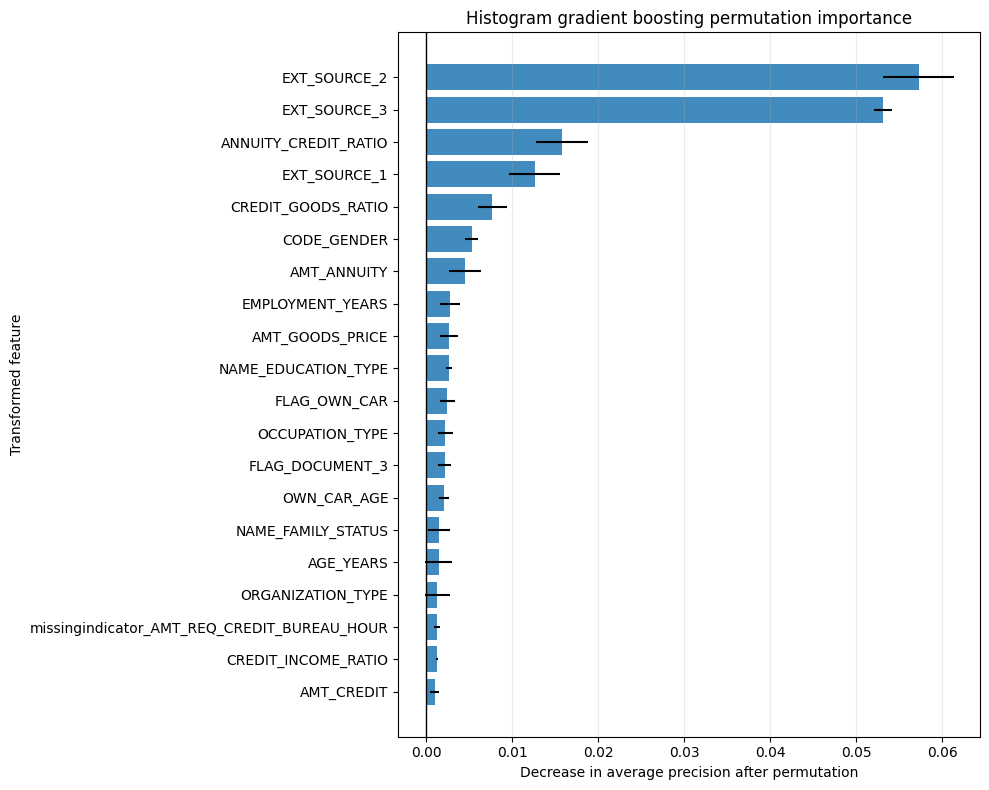

In [38]:
permutation_plot_data = (
    tree_permutation_importance
    .head(20)
    .sort_values(
        "importance_mean"
    )
)

fig, ax = plt.subplots(
    figsize=(10, 8)
)

ax.barh(
    permutation_plot_data[
        "display_feature"
    ],
    permutation_plot_data[
        "importance_mean"
    ],
    xerr=permutation_plot_data[
        "importance_std"
    ],
    color="tab:blue",
    alpha=0.85,
)

ax.axvline(
    0,
    color="black",
    linewidth=1,
)

ax.set(
    xlabel=(
        "Decrease in average precision "
        "after permutation"
    ),
    ylabel="Transformed feature",
    title=(
        "Histogram gradient boosting "
        "permutation importance"
    ),
)

ax.grid(
    axis="x",
    alpha=0.25,
)

plt.tight_layout()
plt.show()

### Interpretability findings

Histogram gradient boosting relies most strongly on the three external risk
scores. `EXT_SOURCE_2` and `EXT_SOURCE_3` produce the largest decreases in
holdout average precision when permuted.

The engineered affordability variables are also informative.
`ANNUITY_CREDIT_RATIO` and `CREDIT_GOODS_RATIO` appear among the most important
features, supporting the usefulness of the feature-engineering stage.

Permutation importance measures predictive reliance rather than causal effect
or direction of association. Importance may also be shared or diluted among
correlated variables.

Logistic-regression coefficients provide complementary directional information.
Higher external scores are associated with lower predicted default risk, while
unemployment is associated with higher predicted risk. Large coefficients for
rare categorical levels must be interpreted cautiously because their estimates
may be unstable.

`CODE_GENDER` appears among the important gradient-boosting features. Any
production use of this variable would require explicit fairness, legal and
model-governance review.

## 9. Phase 05 conclusion

Histogram gradient boosting is retained as the final predictive candidate
for the business-analysis phase. On the protected holdout, it achieves
stronger ROC-AUC and average precision than unweighted logistic regression,
while also obtaining slightly lower Brier score and log-loss. Paired
bootstrap intervals support the observed performance advantage.

Unweighted logistic regression remains the transparent benchmark. Its
coefficients provide directional information, but rare one-hot categories
and correlated financial variables require cautious interpretation.

The F1-maximizing thresholds are diagnostic operating points selected from
development out-of-fold predictions. They are not final approval or
rejection rules. Phase 06 must choose business policies using explicit
costs, capacity constraints and risk appetite.

No further model family, feature, hyperparameter, calibration method or
threshold may be selected from this holdout without invalidating its role
as a protected final evaluation sample.

## 10. Export Phase 05 artifacts

The exported prediction tables are the handoff to Phase 06. They preserve
applicant identifiers, observed targets and model probabilities. All
business-policy analysis must treat these probabilities as frozen.

In [39]:
TABLE_OUTPUT_DIR = (
    PROJECT_ROOT
    / "reports"
    / "tables"
)

TABLE_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

tables_to_export = {
    "05_selected_cv_results.csv": (
        selected_cv_results
    ),
    "05_oof_probabilities.csv": (
        oof_probabilities
    ),
    "05_oof_metrics.csv": (
        oof_metrics
    ),
    "05_development_thresholds.csv": (
        development_thresholds
    ),
    "05_holdout_probabilities.csv": (
        holdout_probabilities
    ),
    "05_holdout_probability_metrics.csv": (
        holdout_probability_metrics
    ),
    "05_holdout_threshold_metrics.csv": (
        holdout_threshold_metrics
    ),
    "05_holdout_metric_intervals.csv": (
        holdout_metric_intervals
    ),
    "05_holdout_model_differences.csv": (
        holdout_model_differences
    ),
    "05_holdout_calibration_table.csv": (
        holdout_calibration_table
    ),
    "05_holdout_calibration_summary.csv": (
        holdout_calibration_summary
    ),
    "05_logistic_coefficients.csv": (
        logistic_coefficients
    ),
    "05_tree_permutation_importance.csv": (
        tree_permutation_importance
    ),
    "05_tree_categorical_audit.csv": (
        tree_categorical_audit
    ),
}

for filename, table in (
    tables_to_export.items()
):
    table.to_csv(
        TABLE_OUTPUT_DIR / filename,
        index=False,
    )

exported_phase_05_files = sorted(
    path.name
    for path in TABLE_OUTPUT_DIR.glob(
        "05_*.csv"
    )
)

exported_phase_05_files

['05_development_thresholds.csv',
 '05_holdout_calibration_summary.csv',
 '05_holdout_calibration_table.csv',
 '05_holdout_metric_intervals.csv',
 '05_holdout_model_differences.csv',
 '05_holdout_probabilities.csv',
 '05_holdout_probability_metrics.csv',
 '05_holdout_threshold_metrics.csv',
 '05_logistic_coefficients.csv',
 '05_oof_metrics.csv',
 '05_oof_probabilities.csv',
 '05_selected_cv_results.csv',
 '05_tree_categorical_audit.csv',
 '05_tree_permutation_importance.csv']

In [40]:
expected_export_files = set(
    tables_to_export
)

missing_export_files = (
    expected_export_files
    - set(exported_phase_05_files)
)

assert not missing_export_files, (
    "Missing Phase 05 exports: "
    f"{sorted(missing_export_files)}"
)

assert (
    len(oof_probabilities)
    == len(X_development_raw)
)

assert (
    len(holdout_probabilities)
    == len(X_holdout_raw)
)

assert (
    tree_categorical_audit[
        "expected_as_categorical"
    ]
    .eq(
        tree_categorical_audit[
            "fitted_as_categorical"
        ]
    )
    .all()
)

phase_05_status = pd.Series(
    {
        "selected_model": (
            "hist_gradient_boosting"
        ),
        "benchmark_model": (
            "logistic_unweighted"
        ),
        "holdout_rows": len(
            X_holdout_raw
        ),
        "exported_files": len(
            expected_export_files
        ),
        "categorical_audit_passed": True,
        "status": "complete",
    },
    name="phase_05",
)

phase_05_status

selected_model              hist_gradient_boosting
benchmark_model                logistic_unweighted
holdout_rows                                 61503
exported_files                                  14
categorical_audit_passed                      True
status                                    complete
Name: phase_05, dtype: object